In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("lakehouse.duckdb")
sns.set_style("whitegrid")
con.execute("SHOW TABLES").df()

,name
0,dim_cliente
1,dim_producto
2,fact_ventas
3,raw_customers
4,raw_orders
5,raw_products
6,stage_customers
7,stage_orders
8,stage_products


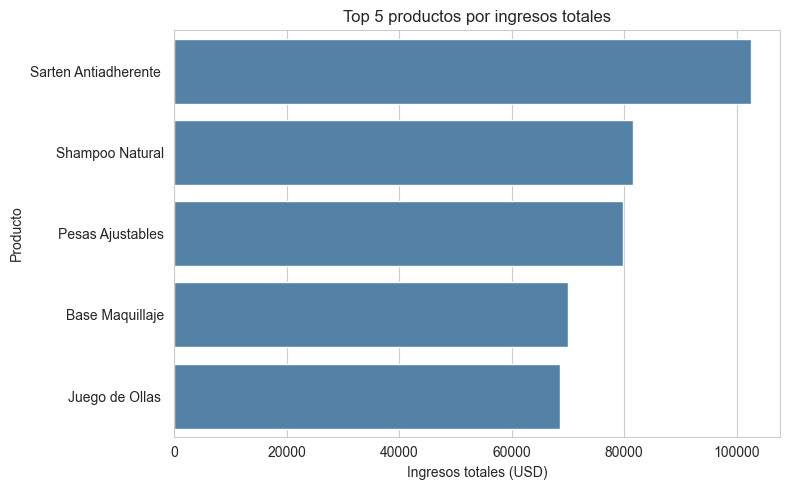

In [2]:
#Grafico 1: Top 5 productos por ingresos
df_top5 = con.execute("""
    SELECT p.product_name, SUM(f.total_amount_usd) AS ingresos_totales
    FROM fact_ventas f
    JOIN dim_producto p ON f.product_id = p.product_id
    GROUP BY p.product_name
    ORDER BY ingresos_totales DESC
    LIMIT 5
""").df()

plt.figure(figsize=(8,5))
sns.barplot(data=df_top5, x="ingresos_totales", y="product_name", color="steelblue")
plt.title("Top 5 productos por ingresos totales")
plt.xlabel("Ingresos totales (USD)")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

**Top 5 productos por ingresos.** Este gráfico muestra los 5 productos que 
generaron mayores ingresos totales considerando todas las transacciones 
registradas. Identificar estos productos permite priorizar su disponibilidad 
en inventario y evaluar si existe una categoría predominante entre ellos, lo 
cual puede orientar decisiones de abastecimiento o campañas de marketing 
hacia los productos con mayor impacto en los ingresos del negocio.

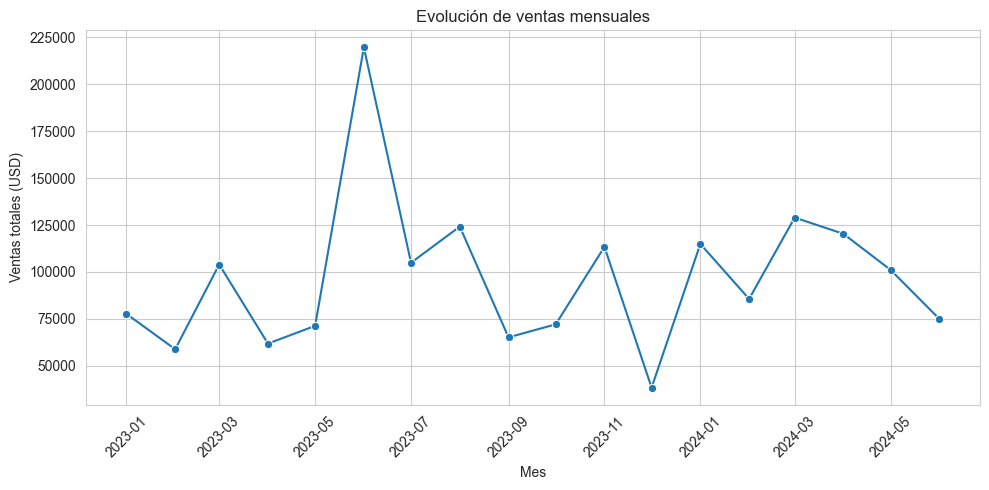

In [3]:
#Grafico de linea de evolución de ventas mes a mes
df_mensual = con.execute("""
    SELECT 
        DATE_TRUNC('month', order_date) AS mes,
        SUM(total_amount_usd) AS ventas_totales
    FROM fact_ventas
    WHERE order_date IS NOT NULL
    GROUP BY DATE_TRUNC('month', order_date)
    ORDER BY mes
""").df()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_mensual, x="mes", y="ventas_totales", marker="o")
plt.title("Evolución de ventas mensuales")
plt.xlabel("Mes")
plt.ylabel("Ventas totales (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evolución de ventas mensuales.** Este gráfico permite observar la tendencia 
de ventas a lo largo del tiempo, identificando posibles meses de mayor o 
menor actividad comercial. Detectar estos patrones es útil para anticipar 
necesidades de stock, planificar campañas en los meses de menor venta, o 
entender si el negocio está en una fase de crecimiento, estabilidad o 
declive.

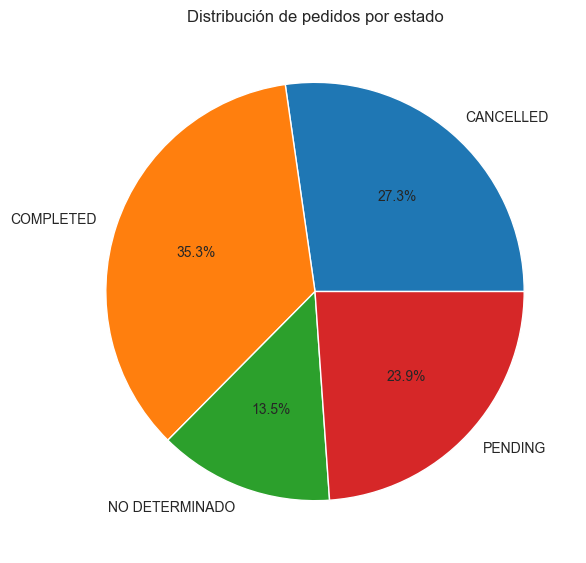

In [4]:
#Grafico circulas con el % de pedidos por estado
df_status = con.execute("""
    SELECT status, COUNT(*) AS total
    FROM fact_ventas
    GROUP BY status
""").df()

plt.figure(figsize=(6,6))
plt.pie(df_status["total"], labels=df_status["status"], autopct="%1.1f%%")
plt.title("Distribución de pedidos por estado")
plt.tight_layout()
plt.show()

**Distribución de pedidos por estado.** Este gráfico muestra qué porcentaje 
del total de pedidos se encuentra en cada estado (completado, pendiente, 
cancelado). Un porcentaje alto de pedidos cancelados podría señalar 
problemas en el proceso de fulfillment, pago o stock, mientras que una alta 
proporción de pedidos completados refleja una operación de ventas saludable. 
Los pedidos marcados como "NO DETERMINADO" corresponden a estados que no 
calzaban con las 3 categorías oficiales del negocio tras la limpieza de 
datos.

In [6]:
con.close()

## Resumen - Reporte de Visualizaciones

Se generaron 3 visualizaciones a partir de la capa ANALYTICS (`fact_ventas` 
y `dim_producto`), respondiendo preguntas concretas de negocio: productos 
con mayores ingresos, evolución de ventas en el tiempo, y distribución de 
pedidos por estado. Cada gráfico incluye título, ejes etiquetados y un 
párrafo de interpretación.